In [1]:
# ============================================================
# CELDA 1 — Imports y carga de datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

# Rutas
BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(BASE, 'data', 'processed')
REPORTS   = os.path.join(BASE, 'reports')
MODELS    = os.path.join(BASE, 'src', 'models')

# Carga
df = pd.read_csv(os.path.join(PROCESSED, 'listings_clean.csv'), low_memory=False)

print(f"Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"Precio mediano global: {df['price'].median():.0f}€/noche")

Dataset cargado: 69,142 filas | 33 columnas
Precio mediano global: 114€/noche


In [3]:
# ============================================================
# CELDA 2 — Preparación de features para precio
# ============================================================

# Encoders
le_ciudad = LabelEncoder()
le_barrio = LabelEncoder()
le_room   = LabelEncoder()

df_model = df.copy()
df_model['ciudad_enc'] = le_ciudad.fit_transform(df_model['ciudad'])
df_model['barrio_enc'] = le_barrio.fit_transform(df_model['neighbourhood_cleansed'])
df_model['room_enc']   = le_room.fit_transform(df_model['room_type'])

# Features para predecir precio
# No incluimos variables de reseñas de actividad (leakage)
# Sí incluimos puntuaciones porque el precio se fija antes de conocerlas
FEATURES = [
    'ciudad_enc', 'barrio_enc', 'room_enc',
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'minimum_nights', 'availability_365',
    'host_is_superhost', 'host_listings_count',
    'instant_bookable',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
]

TARGET = 'price'

df_model2 = df_model[FEATURES + [TARGET]].dropna().copy()

# Filtramos outliers extremos (percentil 99)
p99 = df_model2[TARGET].quantile(0.99)
df_model2 = df_model2[df_model2[TARGET] <= p99]

print(f"Dataset para modelado: {len(df_model2):,} filas")
print(f"Precio máximo tras filtro p99: {p99:.0f}€")
print(f"Precio mediano: {df_model2[TARGET].median():.0f}€")

X = df_model2[FEATURES]
y = df_model2[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Precio medio train: {y_train.mean():.0f}€")
print(f"Precio medio test:  {y_test.mean():.0f}€")

Dataset para modelado: 52,547 filas
Precio máximo tras filtro p99: 719€
Precio mediano: 117€

Train: 42,037 | Test: 10,510
Precio medio train: 146€
Precio medio test:  148€


In [4]:
# ============================================================
# CELDA 3 — Entrenamiento Random Forest
# ============================================================

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Entrenando Random Forest...")
modelo_rf.fit(X_train, y_train)
print("✅ Modelo entrenado")

y_pred = modelo_rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n=== MÉTRICAS — Random Forest Precio ===")
print(f"MAE:  {mae:.2f}€")
print(f"RMSE: {rmse:.2f}€")
print(f"R²:   {r2:.4f}  ({r2*100:.1f}%)")

Entrenando Random Forest...
✅ Modelo entrenado

=== MÉTRICAS — Random Forest Precio ===
MAE:  37.85€
RMSE: 59.54€
R²:   0.6963  (69.6%)


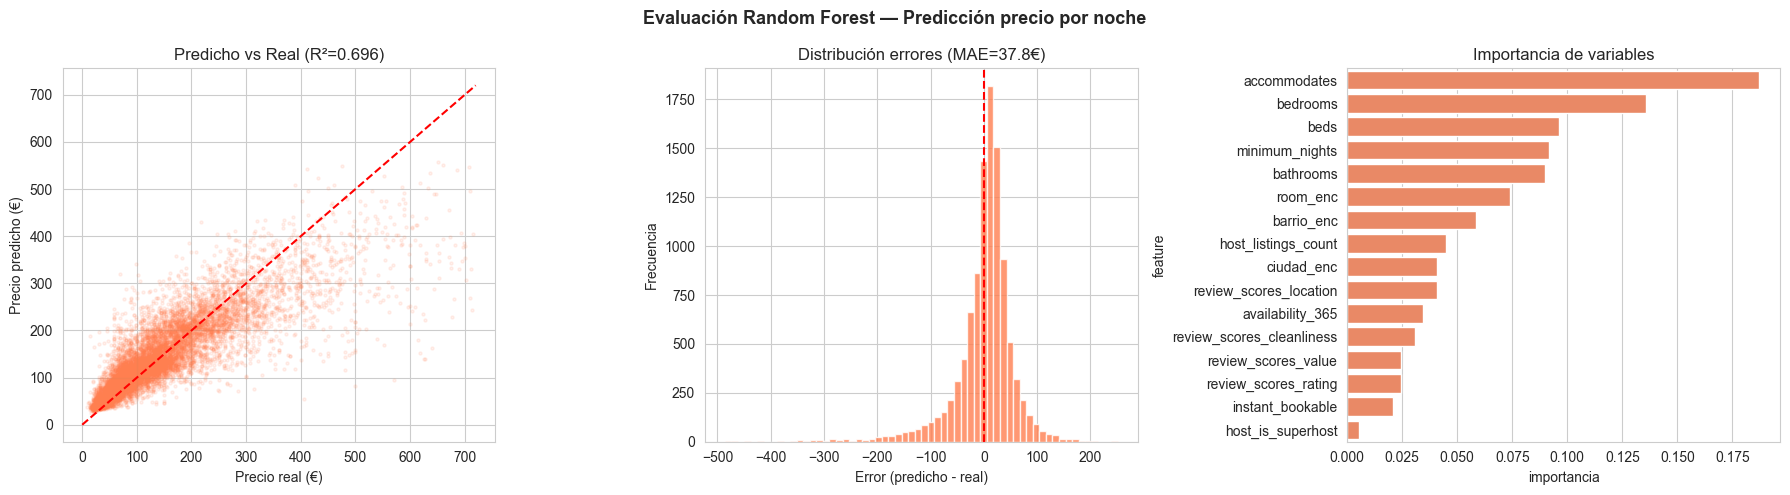


=== IMPORTANCIA DE VARIABLES ===
                  feature  importancia
             accommodates     0.187268
                 bedrooms     0.135938
                     beds     0.096424
           minimum_nights     0.091645
                bathrooms     0.089930
                 room_enc     0.073927
               barrio_enc     0.058599
      host_listings_count     0.044945
               ciudad_enc     0.040844
   review_scores_location     0.040585
         availability_365     0.034606
review_scores_cleanliness     0.030890
      review_scores_value     0.024299
     review_scores_rating     0.024256
         instant_bookable     0.020633
        host_is_superhost     0.005211


In [6]:
# ============================================================
# CELDA 4 — Evaluación visual
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter predicho vs real
axes[0].scatter(y_test, y_pred, alpha=0.1, s=5, color='coral')
axes[0].plot([0, 720], [0, 720], 'r--', linewidth=1.5)
axes[0].set_xlabel('Precio real (€)')
axes[0].set_ylabel('Precio predicho (€)')
axes[0].set_title(f'Predicho vs Real (R²={r2:.3f})')

# Distribución errores
errores = y_pred - y_test
axes[1].hist(errores, bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Error (predicho - real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución errores (MAE={mae:.1f}€)')

# Importancia variables
importancias = pd.DataFrame({
    'feature': FEATURES,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

sns.barplot(data=importancias, x='importancia', y='feature',
            color='coral', ax=axes[2])
axes[2].set_title('Importancia de variables')

plt.suptitle('Evaluación Random Forest — Predicción precio por noche',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'rf_evaluacion.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n=== IMPORTANCIA DE VARIABLES ===")
print(importancias.to_string(index=False))

In [7]:
# ============================================================
# CELDA 5 — Guardado del modelo
# ============================================================

ruta_modelo = os.path.join(MODELS, 'rf_precio.pkl')
with open(ruta_modelo, 'wb') as f:
    pickle.dump(modelo_rf, f)

encoders_rf = {
    'le_ciudad': le_ciudad,
    'le_barrio': le_barrio,
    'le_room':   le_room,
    'features':  FEATURES
}
ruta_encoders = os.path.join(MODELS, 'encoders_rf_precio.pkl')
with open(ruta_encoders, 'wb') as f:
    pickle.dump(encoders_rf, f)

metricas_rf = {
    'mae':    mae,
    'rmse':   rmse,
    'r2':     r2,
    'n_train': len(X_train),
    'n_test':  len(X_test),
    'precio_mediano': float(df_model2[TARGET].median())
}
ruta_metricas = os.path.join(MODELS, 'metricas_rf_precio.pkl')
with open(ruta_metricas, 'wb') as f:
    pickle.dump(metricas_rf, f)

print("✅ Modelo guardado:", ruta_modelo)
print("✅ Encoders guardados:", ruta_encoders)
print("✅ Métricas guardadas:", ruta_metricas)

for ruta in [ruta_modelo, ruta_encoders, ruta_metricas]:
    tam = os.path.getsize(ruta) / (1024*1024)
    print(f"   {os.path.basename(ruta)}: {tam:.1f} MB")

✅ Modelo guardado: /Users/ivannavarrosuero/tfm_vut/src/models/rf_precio.pkl
✅ Encoders guardados: /Users/ivannavarrosuero/tfm_vut/src/models/encoders_rf_precio.pkl
✅ Métricas guardadas: /Users/ivannavarrosuero/tfm_vut/src/models/metricas_rf_precio.pkl
   rf_precio.pkl: 100.6 MB
   encoders_rf_precio.pkl: 0.0 MB
   metricas_rf_precio.pkl: 0.0 MB
